In [168]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

In [169]:
ACOUSTIC_DIR = GENERATED_DIR / "acoustic"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic_frame"

In [170]:
DATA_SIZE = 10 # TODO: remove; just for prototyping

acoustic_paths = sorted(ACOUSTIC_DIR.glob("*"))[:DATA_SIZE] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:DATA_SIZE]
len(acoustic_paths), len(linguistic_paths)

(10, 10)

In [171]:
acoustic_arrays = [np.load(path) for path in acoustic_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

In [172]:
# Truncate, same length
acoustic_arrays = [ac_arr[:len(ln_arr)] for ac_arr, ln_arr in zip(acoustic_arrays, linguistic_arrays)]

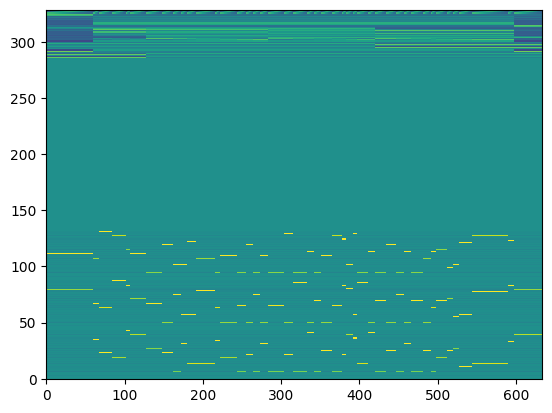

In [173]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [174]:
linguistic_arrays[0].shape

(634, 329)

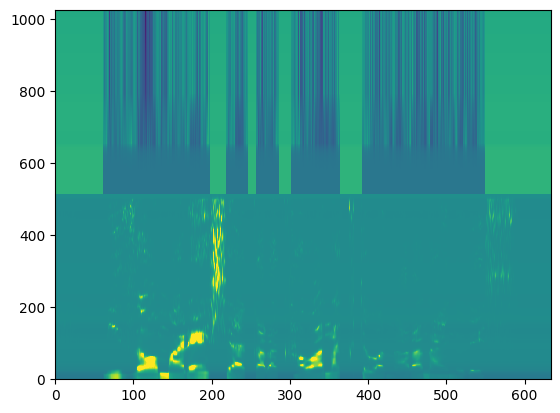

In [175]:
plt.imshow(acoustic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [273]:
f0_arrays = [arr[:, 0:0 + 1] for arr in acoustic_arrays]
sp_arrays = [arr[:, 1:1 + 513] for arr in acoustic_arrays]
ap_arrays = [arr[:, 1 + 513: 1 + 513 + 513] for arr in acoustic_arrays]

In [274]:
dataset = tf.data.Dataset.from_tensor_slices(
    (
        np.concatenate(linguistic_arrays, axis=0),
        (
            np.concatenate(f0_arrays, axis=0),
            np.concatenate(sp_arrays, axis=0),
            np.concatenate(ap_arrays, axis=0),
        )
    )
).shuffle(2048).batch(1024)

In [275]:
def get_model(input_dim = 329, f0_dim=1, sp_dim=513, ap_dim=513):
    ipt = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256,)(ipt)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(128,)(x)
    x = tf.keras.layers.ReLU()(x)
    sp_res = tf.keras.layers.Reshape((1, -1))(tf.keras.layers.Dense(32, activation='relu')(x))
    ap_res = tf.keras.layers.Reshape((1, -1))(tf.keras.layers.Dense(32, activation='relu')(x))
    x = tf.keras.layers.Dense(64,)(x)
    x = tf.keras.layers.ReLU()(x)

    f0_out = tf.keras.layers.Dense(1, name="f0")(x)

    x = tf.keras.layers.Reshape((1, -1))(x)

    sp_mid = tf.keras.layers.Conv1DTranspose(64, 7, strides=4, padding='same')(x)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(32, 7, strides=4, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.Add()([sp_mid, sp_res])
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(16, 7, strides=4, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(8, 7, strides=4, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(4, 7, strides=2, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(1, 2, strides=1, padding='valid')(sp_mid)
    sp_out = tf.keras.layers.Flatten(name="sp")(sp_mid)

    ap_mid = tf.keras.layers.Conv1DTranspose(64, 7, strides=4, padding='same')(x)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(32, 7, strides=4, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.Add()([ap_mid, ap_res])
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(16, 7, strides=4, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(8, 7, strides=4, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(4, 7, strides=2, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(1, 2, strides=1, padding='valid')(ap_mid)
    ap_out = tf.keras.layers.Flatten(name='ap')(ap_mid)

    model = tf.keras.models.Model(inputs=ipt, outputs=(f0_out, sp_out, ap_out))
    return model

model = get_model()
model.summary()

Model: "model_36"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_46 (InputLayer)          [(None, 329)]        0           []                               
                                                                                                  
 dense_203 (Dense)              (None, 256)          84480       ['input_46[0][0]']               
                                                                                                  
 re_lu_309 (ReLU)               (None, 256)          0           ['dense_203[0][0]']              
                                                                                                  
 dense_204 (Dense)              (None, 128)          32896       ['re_lu_309[0][0]']              
                                                                                           

 anspose)                                                                                         
                                                                                                  
 f0 (Dense)                     (None, 1)            65          ['re_lu_311[0][0]']              
                                                                                                  
 sp (Flatten)                   (None, 513)          0           ['conv1d_transpose_294[0][0]']   
                                                                                                  
 ap (Flatten)                   (None, 513)          0           ['conv1d_transpose_300[0][0]']   
                                                                                                  
Total params: 229,643
Trainable params: 229,643
Non-trainable params: 0
__________________________________________________________________________________________________


In [306]:
from tensorflow.keras.losses import MeanSquaredError as MSE

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=(MSE(), MSE(), MSE()),
              metrics=['MAE'])

In [307]:
model.fit(dataset, epochs=100)

Epoch 1/100
8/8 [==============================] - 1s 39ms/step - loss: 0.2932 - f0_loss: 0.0116 - sp_loss: 0.2449 - ap_loss: 0.0367 - f0_MAE: 0.0595 - sp_MAE: 0.1117 - ap_MAE: 0.1023
Epoch 2/100
8/8 [==============================] - 0s 39ms/step - loss: 0.2874 - f0_loss: 0.0114 - sp_loss: 0.2398 - ap_loss: 0.0362 - f0_MAE: 0.0586 - sp_MAE: 0.1114 - ap_MAE: 0.1015
Epoch 3/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2845 - f0_loss: 0.0112 - sp_loss: 0.2374 - ap_loss: 0.0360 - f0_MAE: 0.0576 - sp_MAE: 0.1116 - ap_MAE: 0.1011
Epoch 4/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2837 - f0_loss: 0.0111 - sp_loss: 0.2367 - ap_loss: 0.0359 - f0_MAE: 0.0573 - sp_MAE: 0.1115 - ap_MAE: 0.1010
Epoch 5/100
8/8 [==============================] - 0s 35ms/step - loss: 0.2833 - f0_loss: 0.0111 - sp_loss: 0.2364 - ap_loss: 0.0358 - f0_MAE: 0.0571 - sp_MAE: 0.1112 - ap_MAE: 0.1008
Epoch 6/100
8/8 [==============================] - 0s 37ms/step - loss: 0.2829 -

8/8 [==============================] - 0s 39ms/step - loss: 0.2798 - f0_loss: 0.0107 - sp_loss: 0.2344 - ap_loss: 0.0348 - f0_MAE: 0.0562 - sp_MAE: 0.1107 - ap_MAE: 0.0993
Epoch 46/100
8/8 [==============================] - 0s 37ms/step - loss: 0.2798 - f0_loss: 0.0107 - sp_loss: 0.2343 - ap_loss: 0.0348 - f0_MAE: 0.0561 - sp_MAE: 0.1105 - ap_MAE: 0.0993
Epoch 47/100
8/8 [==============================] - 0s 39ms/step - loss: 0.2795 - f0_loss: 0.0107 - sp_loss: 0.2341 - ap_loss: 0.0347 - f0_MAE: 0.0560 - sp_MAE: 0.1100 - ap_MAE: 0.0993
Epoch 48/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2789 - f0_loss: 0.0107 - sp_loss: 0.2335 - ap_loss: 0.0347 - f0_MAE: 0.0559 - sp_MAE: 0.1100 - ap_MAE: 0.0992
Epoch 49/100
8/8 [==============================] - 0s 39ms/step - loss: 0.2786 - f0_loss: 0.0107 - sp_loss: 0.2332 - ap_loss: 0.0347 - f0_MAE: 0.0560 - sp_MAE: 0.1101 - ap_MAE: 0.0992
Epoch 50/100
8/8 [==============================] - 0s 39ms/step - loss: 0.2784 - f0_los

8/8 [==============================] - 0s 39ms/step - loss: 0.2760 - f0_loss: 0.0105 - sp_loss: 0.2311 - ap_loss: 0.0344 - f0_MAE: 0.0556 - sp_MAE: 0.1103 - ap_MAE: 0.0987
Epoch 90/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2759 - f0_loss: 0.0105 - sp_loss: 0.2311 - ap_loss: 0.0344 - f0_MAE: 0.0555 - sp_MAE: 0.1103 - ap_MAE: 0.0986
Epoch 91/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2757 - f0_loss: 0.0105 - sp_loss: 0.2309 - ap_loss: 0.0343 - f0_MAE: 0.0555 - sp_MAE: 0.1101 - ap_MAE: 0.0986
Epoch 92/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2757 - f0_loss: 0.0105 - sp_loss: 0.2309 - ap_loss: 0.0343 - f0_MAE: 0.0556 - sp_MAE: 0.1100 - ap_MAE: 0.0986
Epoch 93/100
8/8 [==============================] - 0s 39ms/step - loss: 0.2756 - f0_loss: 0.0105 - sp_loss: 0.2309 - ap_loss: 0.0343 - f0_MAE: 0.0556 - sp_MAE: 0.1098 - ap_MAE: 0.0985
Epoch 94/100
8/8 [==============================] - 0s 38ms/step - loss: 0.2754 - f0_los

20/20 [==============================] - 0s 4ms/step


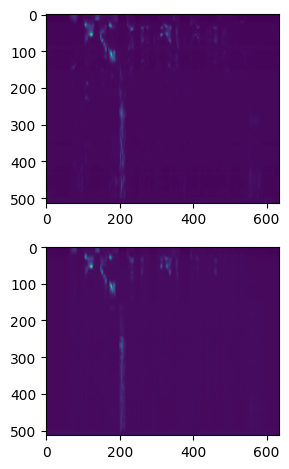

In [320]:
import librosa.display

idx = 0

fig, ax = plt.subplots(2, 1)
ax[0].imshow(sp_arrays[idx].T)
ax[1].imshow(model.predict(linguistic_arrays[idx])[1].T)

plt.tight_layout()

In [321]:
f0, sp, ap = model.predict(linguistic_arrays[idx])

20/20 [==============================] - 0s 4ms/step


In [322]:
mean = np.load("generated/acoustic/mean.npy")
std = np.load("generated/acoustic/std.npy")

def to_audio(f0, sp, ap):
    f0_mean, sp_mean, ap_mean = mean[0:1], mean[1:1+513], mean[1+513:]
    f0_std, sp_std, ap_std = std[0:1], std[1:1+513], std[1+513:]
    f0 = f0_mean + f0_std * f0
    sp = sp_mean + sp_std * sp
    ap = ap_mean + ap_std * ap
    audio = pw.synthesize(f0[:, 0].astype("double"), sp.astype("double"), ap.astype("double"), 22050)
    return audio

In [323]:
import pyworld as pw
import IPython

audio = to_audio(f0, sp, ap)
IPython.display.Audio(audio, rate=22050)

In [324]:
import pyworld as pw
import IPython

audio = to_audio(f0_arrays[idx], sp_arrays[idx], ap_arrays[idx])
IPython.display.Audio(audio, rate=22050)